In [14]:
import os
import sys
import traceback
from pathlib import Path
project_root = Path("/trinity/home/t.samsonov/notebooks/Pirogov/MNE_playground")
sys.path.append(str(project_root))

import optuna
from optuna.trial import TrialState
from lib.optuna import (
    feasible_trials_less_zero,
    load_study_sqlite,
    pareto_front,
    plot_trials_fold_curves,
)


In [11]:
db_path = Path("../5-30-no_time_crop_on_train/tfr_s11.db").resolve()

print("cwd:", os.getcwd())
print("db_path:", db_path)
print("exists:", db_path.exists())
print("is_file:", db_path.is_file())
print("parent exists:", db_path.parent.exists())
print("access parent:", os.access(db_path.parent, os.R_OK | os.X_OK))
print("access file:", os.access(db_path, os.R_OK))

cwd: /beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/notebooks
db_path: /beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/5-30-no_time_crop_on_train/tfr_s11.db
exists: True
is_file: True
parent exists: True
access parent: True
access file: True


In [12]:
db_path = Path("../5-30-no_time_crop_on_train/tfr_s11.db").resolve()

study = load_study_sqlite(db_path=db_path, study_name="tfr_s11")


In [15]:
feasible = feasible_trials_less_zero(study)

print("complete:", sum(t.state == TrialState.COMPLETE for t in study.trials))
print("feasible:", len(feasible))

pareto = pareto_front(feasible, study.directions)
print("Pareto feasible:", len(pareto))

for t in sorted(pareto, key=lambda x: x.values[0], reverse=True)[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")

complete: 100
feasible: 36
Pareto feasible: 4
trial=46 f1=0.7775 slope=-0.017437 params={'lr': 0.0009494540587325816, 'weight_decay': 0.00039797493741031153, 'dropout': 0.4913768140803923, 'batch_size': 32}
trial=58 f1=0.7699 slope=-0.081076 params={'lr': 0.0011771291784507558, 'weight_decay': 0.006351221010640704, 'dropout': 0.5123957592679835, 'batch_size': 16}
trial=44 f1=0.7349 slope=-0.410174 params={'lr': 0.0014905943982528463, 'weight_decay': 0.0009184900818511545, 'dropout': 0.48791101869668757, 'batch_size': 16}
trial=38 f1=0.7033 slope=-0.572902 params={'lr': 0.0016207180989873218, 'weight_decay': 0.0003346220103048386, 'dropout': 0.5563679124791538, 'batch_size': 32}


Trial number: 46
Values (f1, slope): [0.7774725274725275, -0.0174372673034668]
Params: {'lr': 0.0009494540587325816, 'weight_decay': 0.00039797493741031153, 'dropout': 0.4913768140803923, 'batch_size': 32}


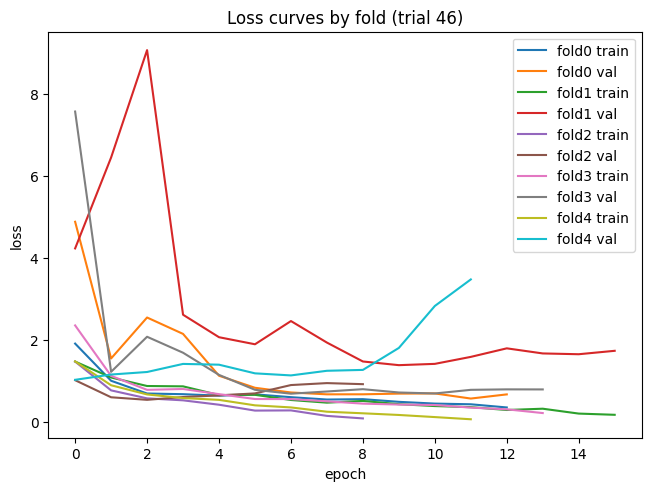

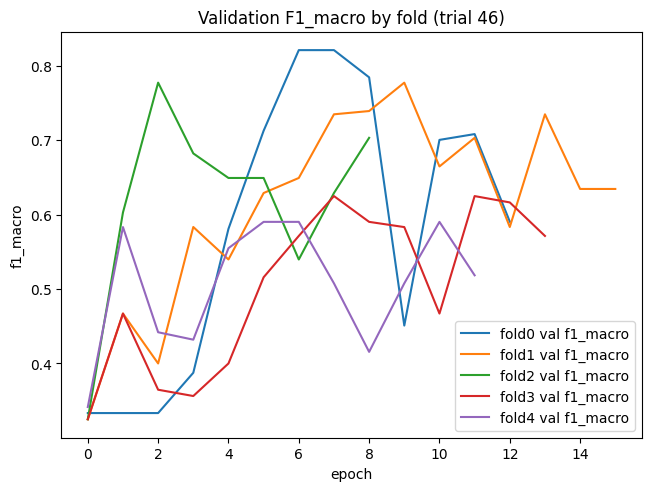

Trial number: 58
Values (f1, slope): [0.7698863636363636, -0.08107575199553194]
Params: {'lr': 0.0011771291784507558, 'weight_decay': 0.006351221010640704, 'dropout': 0.5123957592679835, 'batch_size': 16}


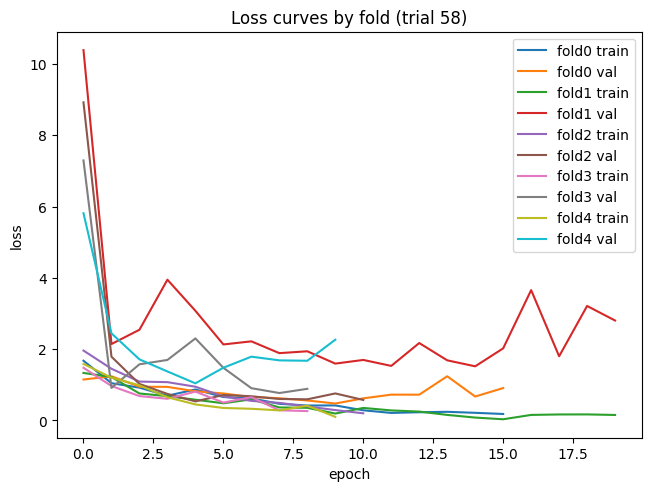

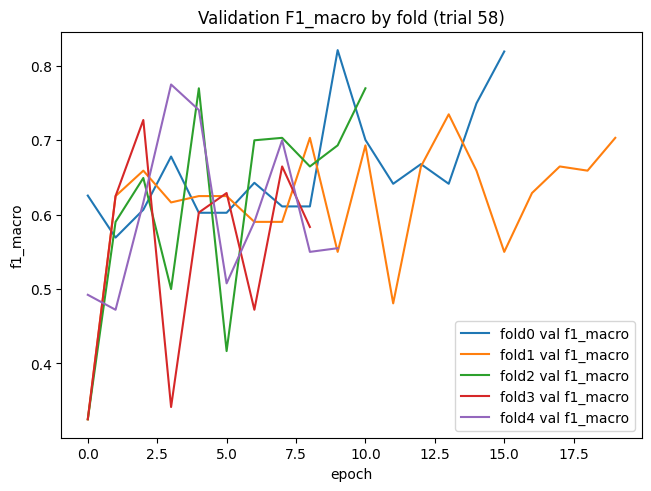

Trial number: 44
Values (f1, slope): [0.7349228611500701, -0.4101739409529129]
Params: {'lr': 0.0014905943982528463, 'weight_decay': 0.0009184900818511545, 'dropout': 0.48791101869668757, 'batch_size': 16}


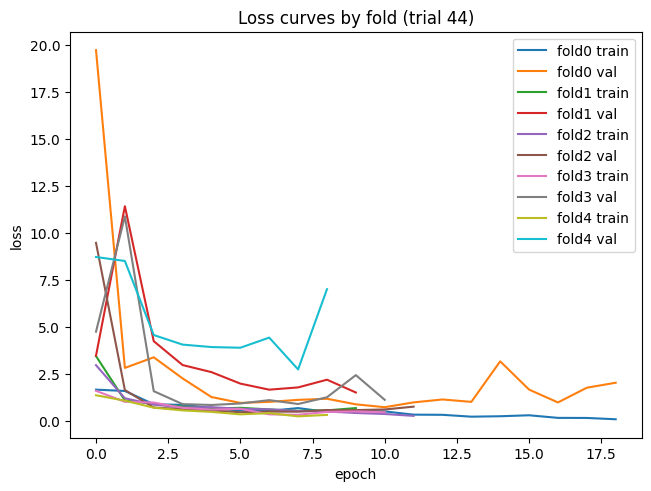

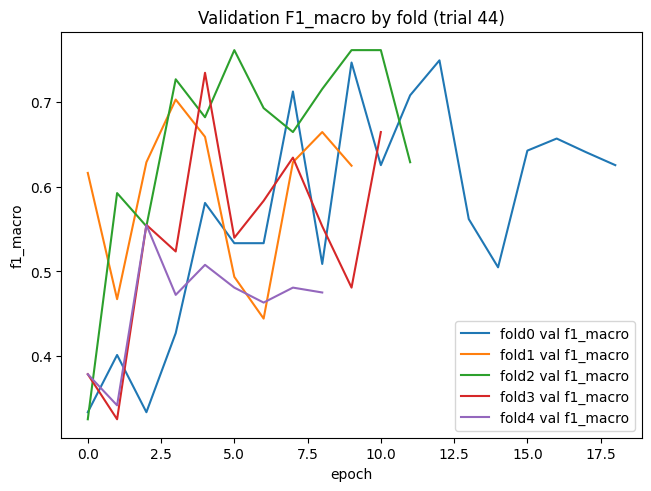

Trial number: 38
Values (f1, slope): [0.7032967032967032, -0.5729016773628468]
Params: {'lr': 0.0016207180989873218, 'weight_decay': 0.0003346220103048386, 'dropout': 0.5563679124791538, 'batch_size': 32}


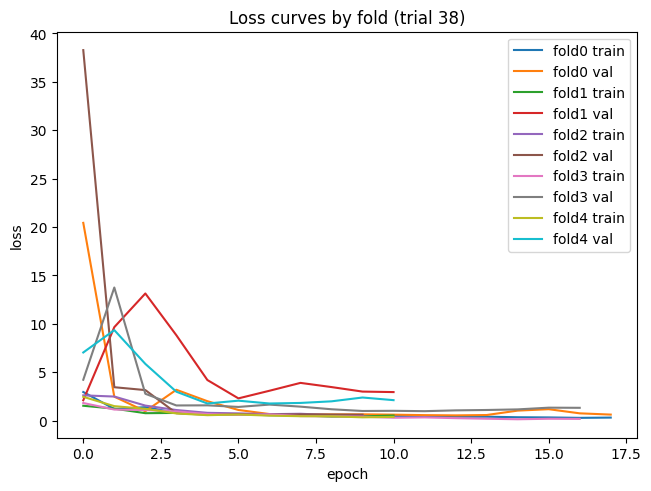

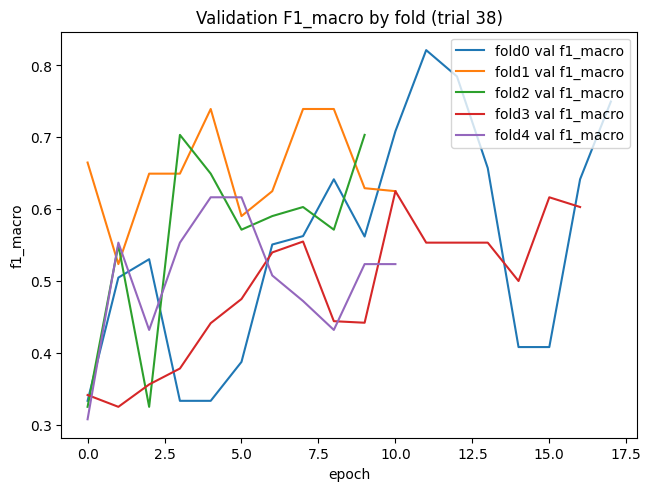

In [16]:
import matplotlib.pyplot as plt

# --- выбери trial по номеру (надёжнее, чем индекс в списке) ---
trial_numbers = [46, 58, 44, 38]
for n in trial_numbers:
    t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == n)
    # более надёжно, если есть пропуски:
    # t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == trial_number)

    print("Trial number:", t.number)
    print("Values (f1, slope):", t.values)
    print("Params:", t.params)
    plot_trials_fold_curves(study, [t.number], show=True)
    continue

    # --- новая номенклатура: fold_curves ---
    fold_curves = t.user_attrs.get("fold_curves", None)

    if fold_curves is not None and len(fold_curves) > 0:
        # 1) Loss curves по фолдам
        plt.figure(constrained_layout=True)
        for fc in fold_curves:
            name = fc.get("split", "fold")
            tr_losses = fc.get("train_losses", [])
            va_losses = fc.get("val_losses", [])
            if tr_losses:
                plt.plot(tr_losses, label=f"{name} train")
            if va_losses:
                plt.plot(va_losses, label=f"{name} val")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title(f"Loss curves by fold (trial {t.number})")
        plt.legend()
        plt.show()

        # 2) F1 curves по фолдам
        plt.figure(constrained_layout=True)
        for fc in fold_curves:
            name = fc.get("split", "fold")
            va_f1s = fc.get("val_f1s", [])
            if va_f1s:
                plt.plot(va_f1s, label=f"{name} val f1_macro")
        plt.xlabel("epoch")
        plt.ylabel("f1_macro")
        plt.title(f"Validation F1_macro by fold (trial {t.number})")
        plt.legend()
        plt.show()

    else:
        # --- fallback: старая номенклатура ---
        train_losses = t.user_attrs.get("train_losses", [])
        val_losses   = t.user_attrs.get("val_losses", [])
        val_f1s      = t.user_attrs.get("val_f1s", [])

        plt.figure(constrained_layout=True)
        if train_losses:
            plt.plot(train_losses, label="train loss")
        if val_losses:
            plt.plot(val_losses, label="val loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title(f"Loss curves (trial {t.number})")
        plt.legend()
        plt.show()

        plt.figure(constrained_layout=True)
        if val_f1s:
            plt.plot(val_f1s, label="val f1_macro")
        plt.xlabel("epoch")
        plt.ylabel("f1_macro")
        plt.title(f"Validation F1_macro (trial {t.number})")
        plt.legend()
        plt.show()

In [ ]:
from optuna.trial import TrialState


def select_trials_top_f1_then_best_losses(
    study,
    *,
    top_f1_n: int = 12,
    top_loss_n: int = 3,
) -> list[int]:
    """
    1) Берем top_f1_n завершенных trial по F1 (по убыванию).
    2) Внутри этого списка выбираем top_loss_n trial с минимальным loss.
    3) Возвращаем выбранные trial в ИСХОДНОМ порядке по F1.

    Пример: после шага 1 получили [4, 5, 2, 1],
    по loss выбрались [1, 5] -> итог вернется как [5, 1].
    """
    complete_trials = [
        t
        for t in study.get_trials(deepcopy=False)
        if t.state == TrialState.COMPLETE and t.values is not None and len(t.values) >= 2
    ]
    if not complete_trials:
        return []

    ranked_by_f1 = sorted(complete_trials, key=lambda t: float(t.values[0]), reverse=True)
    ranked_by_f1 = ranked_by_f1[: max(1, int(top_f1_n))]

    loss_pick_n = min(max(1, int(top_loss_n)), len(ranked_by_f1))

    # Индексы лучших по loss внутри F1-ранжированного списка.
    ranked_indices = list(range(len(ranked_by_f1)))
    best_loss_indices = sorted(
        ranked_indices,
        key=lambda idx: float(ranked_by_f1[idx].values[1]),
    )[:loss_pick_n]

    # Сохраняем порядок по F1.
    keep_idx = set(best_loss_indices)
    selected = [t for i, t in enumerate(ranked_by_f1) if i in keep_idx]

    return [int(t.number) for t in selected]

In [ ]:
from pathlib import Path
from lib.optuna import load_study_sqlite

study_db = Path("notebooks/Pirogov/PreprocessedData/2026-03-31/tfr_s11_transformer.db")
study_name = study_db.stem  # обычно совпадает с именем study в файле

study_s11 = load_study_sqlite(db_path=study_db, study_name=study_name)

selected_trial_numbers = select_trials_top_f1_then_best_losses(
    study_s11,
    top_f1_n=12,   # можно 10..15
    top_loss_n=4,  # можно 3..5
)

print("Selected trial numbers:", selected_trial_numbers)

# Схлопнутый массив в стиле логов:
selected_trials = [
    next(t for t in study_s11.get_trials(deepcopy=False) if t.number == n)
    for n in selected_trial_numbers
]
for t in selected_trials:
    print(
        f"[I] Trial {t.number} values={t.values} params={t.params}"
    )

In [ ]:
# Визуализация по конкретному номеру trial
from lib.optuna import plot_trial_fold_curves

trial_number = selected_trial_numbers[0] if selected_trial_numbers else 0
print("Visualizing trial:", trial_number)

plot_trial_fold_curves(study_s11, trial_number, show=True)

# Если хотите быстро посмотреть все выбранные:
# from lib.optuna import plot_trials_fold_curves
# plot_trials_fold_curves(study_s11, selected_trial_numbers, show=True)